### Author: Reda Achouhad

In [18]:
#ProbLem Statement: You're going out, do you need umbrella.

#States: Rainy, CLoudy and Sunny
#Actions: UmbreLla & No umbrella
#Reward: Dict mapping with each state action pair
#Transition Prob
#Discount Factor

In [19]:
import numpy as np
import matplotlib.pyplot as plt

### Markov Decision Process (MDP) Setup

In this example, we define:
- the states of the environment
- the available actions
- the reward function
- the transition probabilities
- the discount factor

In [20]:
# The States
states = [
    'Rainy', 
    'Cloudy', 
    'Sunny'
]

# The actions
actions = ['Umbrella', 'No Umbrella']

# The rewards
rewards = {
    'Rainy': {
        'Umbrella': {'Rainy': -1, 'Cloudy': -1, 'Sunny': -1},
        'No Umbrella': {'Rainy': -5, 'Cloudy': -4, 'Sunny': -4}
    },
    'Cloudy': {
        'Umbrella': {'Rainy': -1, 'Cloudy': -1, 'Sunny': -1},
        'No Umbrella': {'Rainy': -2, 'Cloudy': -1, 'Sunny': -2}
    },
    'Sunny': {
        'Umbrella': {'Rainy': -3, 'Cloudy': -2, 'Sunny': -2},
        'No Umbrella': {'Rainy': 0, 'Cloudy': 0, 'Sunny': 0}
    }
}
# Transition probabilities
transition_probabilities = {
    'Rainy': {
        "Umbrella": {'Rainy': 0.7, 'Cloudy': 0.3, 'Sunny': 0},
        "No Umbrella": {'Rainy': 0.3, 'Cloudy': 0.4, 'Sunny': 0.3}
    },
    'Cloudy': {
        "Umbrella": {'Rainy': 0.4, 'Cloudy': 0.6, 'Sunny': 0},
        "No Umbrella": {'Rainy': 0, 'Cloudy': 0.7, 'Sunny': 0.3}
    },
    'Sunny': {
        "Umbrella": {'Rainy': 0, 'Cloudy': 0, 'Sunny': 1},
        "No Umbrella": {'Rainy': 0, 'Cloudy': 0.4, 'Sunny': 0.6}
    }
}

# Discount factor (Gamma)
gamma = 0.9




In this case, we will use the value iteration algorithm to solve this MDP (Markov Decision Process)

We will use the bellman equation to find the optimal policy

#### $V^*(s) = \max_a \sum_{s'} P(s' \mid s, a)\,\big[ R(s, a, s') + \gamma V^*(s') \big]$

#### $V_{k+1}(s) = \max_a \sum_{s'} P(s' \mid s, a)\,\big[ R(s, a, s') + \gamma V_k(s') \big]$

**Explanation:**

- $s$ : current state  
- $a$ : action  
- $s'$ : next state  
- $P(s' \mid s, a)$ : transition probability  
- $R(s, a, s')$ : reward  
- $\gamma$ : discount factor (between 0 and 1)

## Value Iteration (Mathematical Definition)

Value Iteration is a dynamic programming method used to compute the optimal value function by repeatedly applying the **Bellman Optimality Equation**.

---

## 1. Relationship between Value and Action-Value Functions

$$
V_k(s) = \max_a Q_k(s, a)
$$

---

## 2. Definition of the Action-Value Function

The action-value function is defined as:

$$
Q_k(s,a) = \sum_{s'} P(s' \mid s, a)\,\big[ R(s, a, s') + \gamma V_k(s') \big]
$$

---

## 3. Value Iteration Update Rule

By substituting $Q_k(s,a)$ into $V_k(s)$, we obtain the iterative update:

$$
V_{k+1}(s) = \max_{a} \sum_{s'} P(s' \mid s, a)\,\big[ R(s, a, s') + \gamma V_k(s') \big]
$$

---

## 4. Definitions

- $V_k(s)$: value function → expected return starting from state $s$ at iteration $k$, following the optimal policy  
- $Q_k(s,a)$: action-value function → expected return starting from state $s$, taking action $a$, then following the optimal policy  
- $s$: current state  
- $a$: action  
- $s'$: next state  
- $P(s' \mid s, a)$: transition probability  
- $R(s, a, s')$: reward  
- $\gamma \in [0,1]$: discount factor  

---

## 5. Optimal Policy Extraction

After convergence, the optimal policy is obtained by:

$$
\pi^*(s) = \arg\max_{a} \sum_{s'} P(s' \mid s, a)\,\big[ R(s, a, s') + \gamma V^*(s') \big]
$$

In [21]:
def value_iteration(states, actions, rewards, transition_probabilities, gamma, theta):

    V = {s: 0 for s in states}
    iteration = 0
    delta_history = []

    while True:
        delta = 0
        new_V = {}

        for s in states:
            action_values = []

            for a in actions:
                q_sa = 0

                for s_next in states:
                    prob = transition_probabilities[s][a][s_next]

                    r = rewards[s][a][s_next]

                    q_sa += prob * (r + gamma * V[s_next])

                action_values.append(q_sa)

            best_value = max(action_values)
            new_V[s] = best_value

            delta = max(delta, abs(best_value - V[s]))

        V = new_V
        iteration += 1
        delta_history.append(delta)

        if delta < theta:
            print(f"Converged after {iteration} iterations")
            break

    # Policy extraction
    policy = {}

    for s in states:
        best_action = None
        best_value = float("-inf")

        for a in actions:
            q_sa = 0

            for s_next in states:
                prob = transition_probabilities[s][a][s_next]
                r = rewards[s][a][s_next]  

                q_sa += prob * (r + gamma * V[s_next])

            if q_sa > best_value:
                best_value = q_sa
                best_action = a

        policy[s] = best_action

    return V, policy, delta_history

In [22]:
value_function, optimal_policy, delta_history = value_iteration(
    states, 
    actions, 
    rewards, 
    transition_probabilities, 
    gamma=0.9,
    theta=1e-7
)

Converged after 152 iterations


In [23]:
print("Optimal Value Function:")
for state, value in value_function.items():
    print(f"{state}: {value:.4f}")

Optimal Value Function:
Rainy: -8.6805
Cloudy: -8.1918
Sunny: -6.4110


In [24]:
print("Optimal Policy:")
for state, action in optimal_policy.items():
    print(f"{state}: {action}")

Optimal Policy:
Rainy: Umbrella
Cloudy: No Umbrella
Sunny: No Umbrella


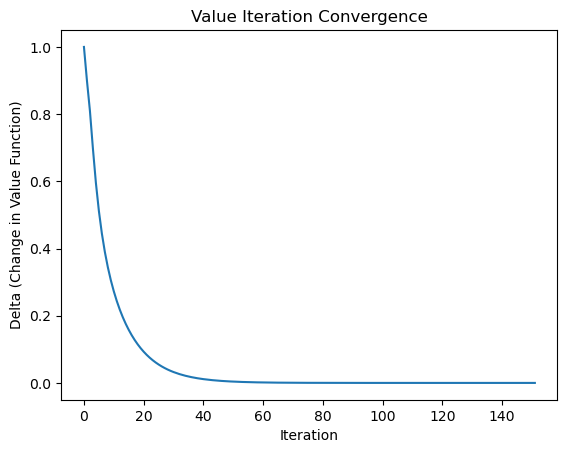

In [25]:
def plot_convergence(delta_history):
    plt.figure()
    plt.plot(delta_history)
    plt.title("Value Iteration Convergence")
    plt.xlabel("Iteration")
    plt.ylabel("Delta (Change in Value Function)")
    plt.show()

plot_convergence(delta_history)